In [2]:
# Importing Libraries
import pandas as pd                              # Pandas: work with and analyze tabular data
from datasets import load_dataset               # Hugging Face: load the job postings dataset
import matplotlib.pyplot as plt                 # Matplotlib: create charts and visualizations


# Loading Data
dataset = load_dataset('lukebarousse/data_jobs') # Download/load Luke's job dataset
df = dataset['train'].to_pandas()                # Convert the dataset into a Pandas DataFrame


# Data Cleanup
df['job_posted_date'] = pd.to_datetime(
    df['job_posted_date']
)  

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the software-job CSV into a new DataFrame
df_US_software_pivot = pd.read_csv(
    "https://lukeb.co/software_csv",
    index_col="job_posted_month"
)

# Display the imported DataFrame
df_US_software_pivot

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
job_posted_month,,,,
January,13619,9827,5108,4348
February,11456,9116,7298,4284
March,11102,8178,5814,4159
April,14037,9209,7232,4220
May,12126,8864,6718,4980
June,12003,8065,5902,4781
July,11914,8061,6839,4344
August,11571,8191,7413,4104
September,14016,8447,6139,4094


In [8]:
# Create a monthly summary of the job postings data so it can be merged
# with the software-job counts from the CSV.
df_US_pivot = (
    df.assign(
        job_posted_month=lambda x: x["job_posted_date"].dt.to_period("M").astype(str)
    )
    .groupby("job_posted_month")
    .size()
    .to_frame("job_count")
    .reset_index()
)

# Display the monthly pivot table
df_US_pivot

,job_posted_month,job_count
0,2023-01,91822
1,2023-02,64578
2,2023-03,64084
3,2023-04,62919
4,2023-05,52104
5,2023-06,61572
6,2023-07,63777
7,2023-08,75162
8,2023-09,62359
9,2023-10,66611


In [24]:
# Merge the monthly job counts with the software-job counts
# by the shared month column.
df_US_merged = (
    df_US_pivot.merge(
        df_US_software_pivot.reset_index(),
        on="job_posted_month",
        how="left"
    )
)

# Display the merged DataFrame
df_US_merged


,job_posted_month,job_count,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,2023-01,91822,NaN,NaN,NaN,NaN
1,2023-02,64578,NaN,NaN,NaN,NaN
2,2023-03,64084,NaN,NaN,NaN,NaN
3,2023-04,62919,NaN,NaN,NaN,NaN
4,2023-05,52104,NaN,NaN,NaN,NaN
5,2023-06,61572,NaN,NaN,NaN,NaN
6,2023-07,63777,NaN,NaN,NaN,NaN
7,2023-08,75162,NaN,NaN,NaN,NaN
8,2023-09,62359,NaN,NaN,NaN,NaN
9,2023-10,66611,NaN,NaN,NaN,NaN


In [16]:
# Find the 5 job-title columns with the highest total number of postings
top_5 = (
    df_US_merged
    .drop(columns='job_count')            # Remove job_count because it is not a job-title column
    .sum(numeric_only=True)               # Sum ONLY numeric columns; ignore text columns like month names
    .sort_values(ascending=False)          # Sort total postings from highest → lowest
    .head(5)                               # Keep only the top 5 job titles
    .index                                 # Get the job-title column names
    .to_list()                             # Convert them into a regular Python list
)

# Display the selected top 5 job titles
top_5

['Front-End Developer',
 'Back-End Developer',
 'Full-Stack Developer',
 'UI/UX Designer']

In [25]:
# Convert the software DataFrame index (January, February, etc.) back into a normal column
df_US_software_pivot = df_US_software_pivot.reset_index()


# Convert month names like "January" into month numbers like 1
df_US_software_pivot['job_posted_month'] = pd.to_datetime(
    df_US_software_pivot['job_posted_month'],
    format='%B'                         # %B means full month name: January, February, etc.
).dt.month                              # Extract ONLY the month number: January → 1


# Convert month numbers into the same YYYY-MM format as the other DataFrame
df_US_software_pivot['job_posted_month'] = (
    '2023-'                             # Add the year in front
    + df_US_software_pivot['job_posted_month']
        .astype(str)                    # Convert number to string: 1 → "1"
        .str.zfill(2)                   # Add leading zero: "1" → "01", "9" → "09"
)


# Merge the two DataFrames using their matching YYYY-MM month values
df_US_merged = df_US_pivot.merge(
    df_US_software_pivot,
    on='job_posted_month',              # Match rows using this column
    how='left'                          # Keep every month from df_US_pivot
)

df_US_merged

,job_posted_month,job_count,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,2023-01,91822,13619,9827,5108,4348
1,2023-02,64578,11456,9116,7298,4284
2,2023-03,64084,11102,8178,5814,4159
3,2023-04,62919,14037,9209,7232,4220
4,2023-05,52104,12126,8864,6718,4980
5,2023-06,61572,12003,8065,5902,4781
6,2023-07,63777,11914,8061,6839,4344
7,2023-08,75162,11571,8191,7413,4104
8,2023-09,62359,14016,8447,6139,4094
9,2023-10,66611,11419,8476,5026,4389


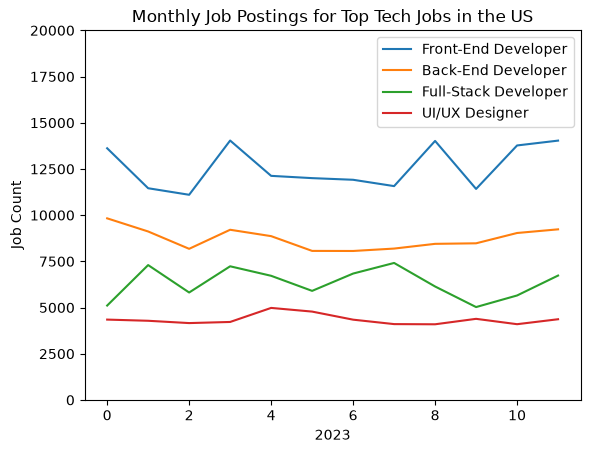

,Front-End Developer,Back-End Developer,Full-Stack Developer,UI/UX Designer
0,13619,9827,5108,4348
1,11456,9116,7298,4284
2,11102,8178,5814,4159
3,14037,9209,7232,4220
4,12126,8864,6718,4980
5,12003,8065,5902,4781
6,11914,8061,6839,4344
7,11571,8191,7413,4104
8,14016,8447,6139,4094
9,11419,8476,5026,4389


In [26]:
# Plot the monthly posting trends for the top 5 job titles
df_US_merged[top_5].plot(kind='line')

# Add a descriptive chart title
plt.title('Monthly Job Postings for Top Tech Jobs in the US')

# Label the x-axis
plt.xlabel('2023')

# Label the y-axis
plt.ylabel('Job Count')

# Set the visible y-axis range from 0 to 20,000
plt.ylim(0, 20000)

# Display a legend showing which line belongs to each job title
plt.legend()

# Render the finished chart
plt.show()

df_US_merged[top_5]